In [8]:
GITHUB_USER = 'Skm48'   # GitHub username
REPO_NAME   = 'MINI_PROJECT'

import os

if not os.path.exists(f'/content/{REPO_NAME}'):
    # First time — clone
    !git clone https://github.com/{GITHUB_USER}/{REPO_NAME}.git
    print('Repo cloned!')
else:
    # Already cloned — pull latest
    !cd /content/{REPO_NAME} && git pull
    print('Pulled latest changes!')

os.chdir(f'/content/{REPO_NAME}')
print(f'Working directory: {os.getcwd()}')

Already up to date.
Pulled latest changes!
Working directory: /content/MINI_PROJECT


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!cp /content/drive/MyDrive/Collab\ Files/Dataset.zip /content/MINI_PROJECT/data/
!unzip -q /content/MINI_PROJECT/data/Dataset.zip -d /content/MINI_PROJECT/data/

In [4]:
# Remove the Mac junk folder and nested duplicate
!rm -rf /content/MINI_PROJECT/data/chest_xray/__MACOSX
!rm -rf /content/MINI_PROJECT/data/chest_xray/chest_xray


In [6]:
!cp /content/drive/MyDrive/Collab\ Files/vgg16_phase1_best.pth models/checkpoints/
!cp /content/drive/MyDrive/Collab\ Files/vgg16_best.pth models/checkpoints/

In [9]:
import torch
import torch.nn as nn
import torchvision.models as models

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Rebuild VGG16 with same structure
vgg16 = models.vgg16(weights='IMAGENET1K_V1')
vgg16.classifier = nn.Sequential(
    nn.Linear(512 * 7 * 7, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 2),
)

# Load your saved weights
vgg16.load_state_dict(torch.load('models/checkpoints/vgg16_phase1_best.pth', map_location='cpu'))
vgg16 = vgg16.to('cpu')
vgg16.eval()

device = torch.device('cpu')
print("Loaded on CPU — slower but works")

Loaded on CPU — slower but works


In [12]:
from src.dataset import get_dataloaders
from src.utils import load_config

config = load_config()
loaders = get_dataloaders(config)

Total images found: 5856
  By original split: {'train': np.int64(5216), 'test': np.int64(624), 'val': np.int64(16)}
  By label: {1: np.int64(4273), 0: np.int64(1583)}

Merged train+val: 5232 images
Original test kept: 624 images

New split sizes:
  Train: 4650  (Normal: 1199, Pneumonia: 3451)
  Val:   582  (Normal: 150, Pneumonia: 432)
  Test:  624  (Normal: 234, Pneumonia: 390)

Split indices saved to: data/split_indices.csv

Class weights: Normal=1.939, Pneumonia=0.674

DataLoaders ready:
  Train: 146 batches (4650 images)
  Val:   19 batches (582 images)
  Test:  20 batches (624 images)


In [13]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 103.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=59d14ead0f54a3b909360323f36f7f806734edbf989097b4077fadb0fb3b77f3
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [15]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [17]:
# The last conv layer in VGG16 — this is where we extract the heatmap
target_layer = [vgg16.features[28]]

cam = GradCAM(model=vgg16, target_layers=target_layer)

In [19]:
# Run this to see what layer 28 is
print(vgg16.features[28])

Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))


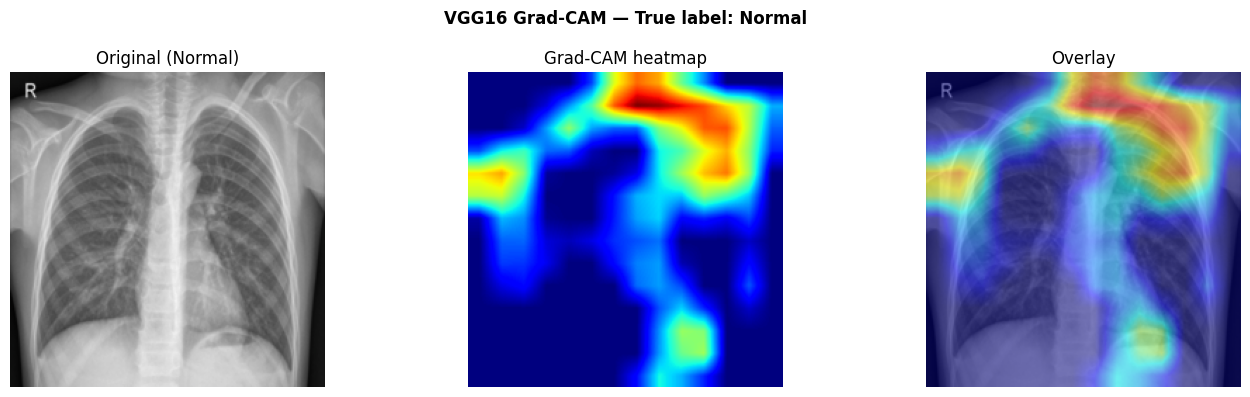

In [21]:
# Get one image from test set
images, labels = next(iter(loaders['test']))
img_tensor = images[0].unsqueeze(0).to(device)
label = labels[0].item()
label_names = {0: 'Normal', 1: 'Pneumonia'}

# Generate Grad-CAM
grayscale_cam = cam(input_tensor=img_tensor)
grayscale_cam = grayscale_cam[0]  # first image in batch

# Un-normalise the image for display
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_display = images[0].permute(1, 2, 0).numpy()  # CHW → HWC
img_display = std * img_display + mean
img_display = np.clip(img_display, 0, 1)

# Overlay heatmap on image
cam_image = show_cam_on_image(img_display, grayscale_cam, use_rgb=True)

# Show
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(img_display)
axes[0].set_title(f"Original ({label_names[label]})")
axes[0].axis('off')

axes[1].imshow(grayscale_cam, cmap='jet')
axes[1].set_title("Grad-CAM heatmap")
axes[1].axis('off')

axes[2].imshow(cam_image)
axes[2].set_title("Overlay")
axes[2].axis('off')

plt.suptitle(f"VGG16 Grad-CAM — True label: {label_names[label]}", fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/gradcam/vgg16_sample.png', dpi=150, bbox_inches='tight')
plt.show()

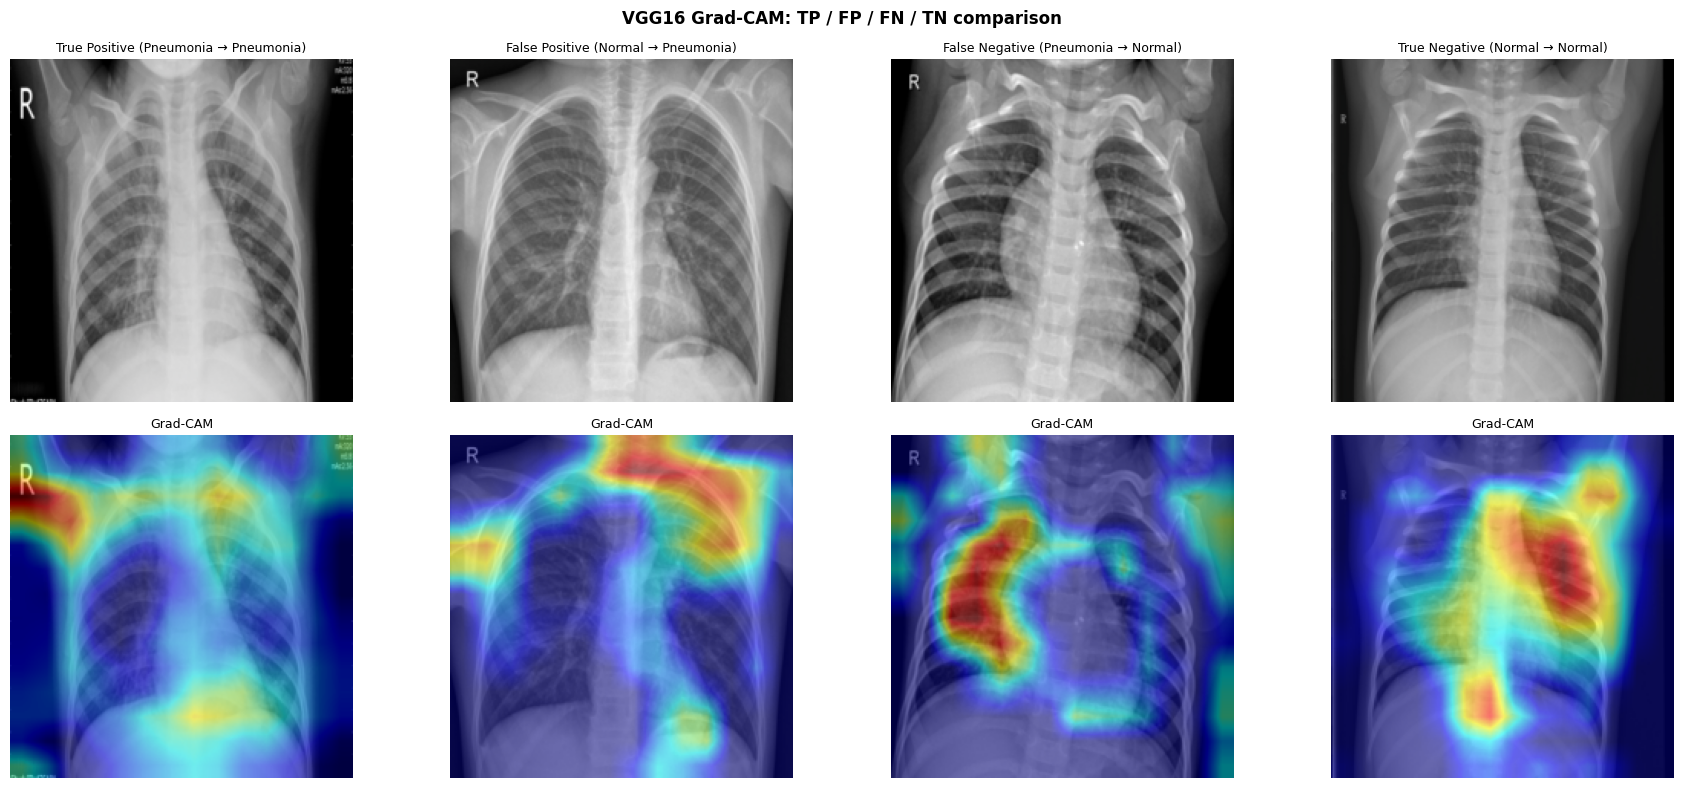

In [22]:
# Collect predictions to find TP, FP, FN cases
vgg16.eval()
all_images, all_labels, all_preds = [], [], []

with torch.no_grad():
    for images, labels in loaders['test']:
        outputs = vgg16(images.to(device))
        preds = outputs.argmax(dim=1).cpu()
        all_images.extend(images)
        all_labels.extend(labels.numpy())
        all_preds.extend(preds.numpy())

# Find one of each case
tp_idx, fp_idx, fn_idx, tn_idx = None, None, None, None
for i in range(len(all_labels)):
    if all_labels[i] == 1 and all_preds[i] == 1 and tp_idx is None:
        tp_idx = i
    if all_labels[i] == 0 and all_preds[i] == 1 and fp_idx is None:
        fp_idx = i
    if all_labels[i] == 1 and all_preds[i] == 0 and fn_idx is None:
        fn_idx = i
    if all_labels[i] == 0 and all_preds[i] == 0 and tn_idx is None:
        tn_idx = i

cases = {
    "True Positive (Pneumonia → Pneumonia)": tp_idx,
    "False Positive (Normal → Pneumonia)": fp_idx,
    "False Negative (Pneumonia → Normal)": fn_idx,
    "True Negative (Normal → Normal)": tn_idx,
}

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for col, (case_name, idx) in enumerate(cases.items()):
    img_tensor = all_images[idx].unsqueeze(0).to(device)

    # Grad-CAM
    grayscale_cam = cam(input_tensor=img_tensor)
    grayscale_cam = grayscale_cam[0]

    # Un-normalise
    img_display = all_images[idx].permute(1, 2, 0).numpy()
    img_display = std * img_display + mean
    img_display = np.clip(img_display, 0, 1)

    cam_image = show_cam_on_image(img_display, grayscale_cam, use_rgb=True)

    # Top row: original
    axes[0, col].imshow(img_display)
    axes[0, col].set_title(case_name, fontsize=9)
    axes[0, col].axis('off')

    # Bottom row: Grad-CAM overlay
    axes[1, col].imshow(cam_image)
    axes[1, col].set_title("Grad-CAM", fontsize=9)
    axes[1, col].axis('off')

plt.suptitle("VGG16 Grad-CAM: TP / FP / FN / TN comparison", fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/gradcam/vgg16_comparison_grid.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
!cd /content/MINI_PROJECT && git config user.name "Skm48"
!cd /content/MINI_PROJECT && git config user.email "skm48@student.le.ac.uk"

In [26]:

!cd /content/MINI_PROJECT && git remote set-url origin https://Skm48@github.com/Skm48/MINI_PROJECT.git

In [28]:

!cp /content/drive/My\ Drive/Colab\ Notebooks/04_gradcam.ipynb/content/MINI_PROJECT/notebooks/

cp: missing destination file operand after '/content/drive/My Drive/Colab Notebooks/04_gradcam.ipynb/content/MINI_PROJECT/notebooks/'
Try 'cp --help' for more information.


In [ ]:
!git add .
!cd /content/MINI_PROJECT && git commit -m "add: VGG16 Exlpainability Steve"